In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame.copy()

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df['target'].value_counts())
print("Target names:", wine.target_names)
print("Feature names:", wine.feature_names)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [2]:
df['wine_class'] = df['target'].map({
    0: wine.target_names[0],
    1: wine.target_names[1],
    2: wine.target_names[2]
})

print(df[['target', 'wine_class']].head())

   target wine_class
0       0    class_0
1       0    class_0
2       0    class_0
3       0    class_0
4       0    class_0


In [3]:
print(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
wine_class                      0
dtype: int64


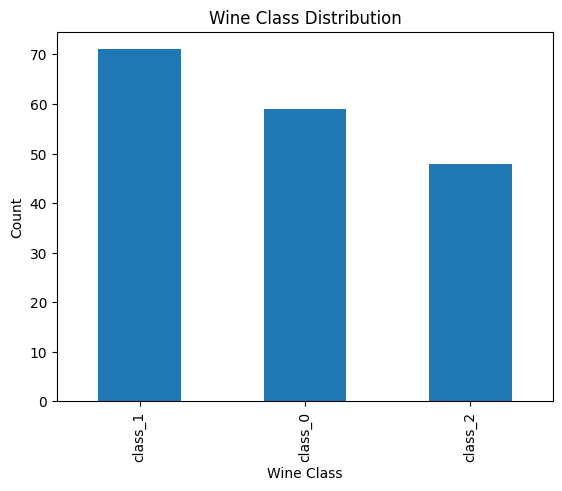

In [4]:
df['wine_class'].value_counts().plot(kind='bar')
plt.title('Wine Class Distribution')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()

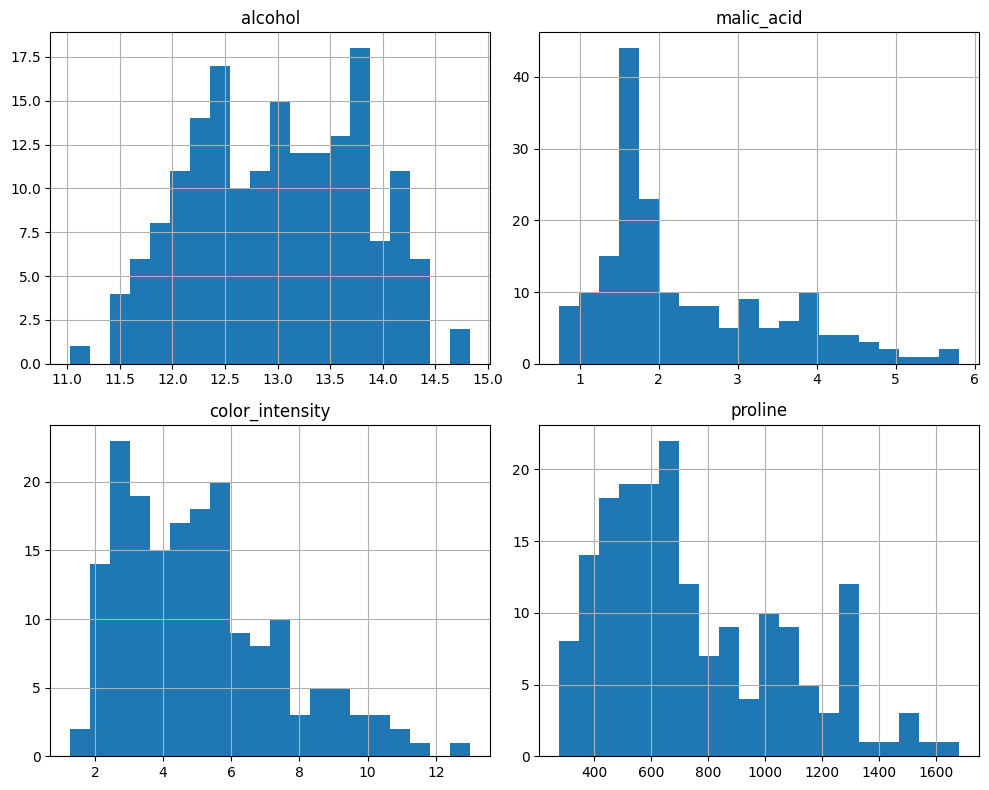

In [5]:
top_cols = ['alcohol', 'malic_acid', 'color_intensity', 'proline']

df[top_cols].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

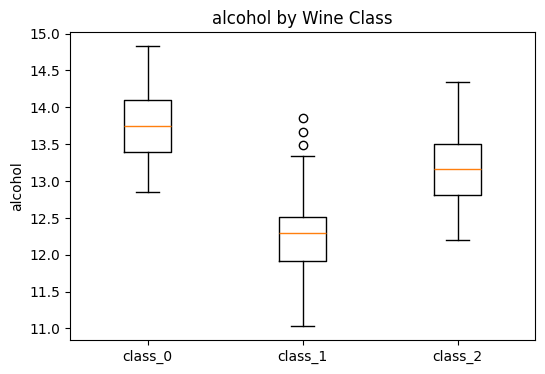

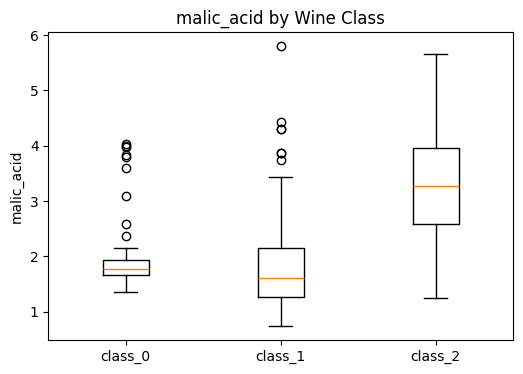

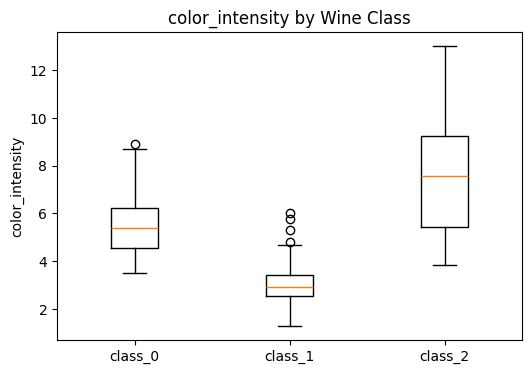

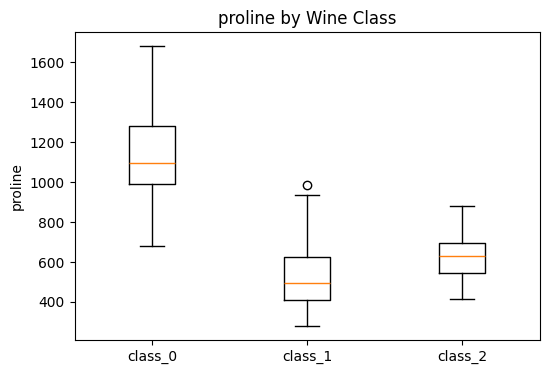

In [6]:
for col in top_cols:
    plt.figure(figsize=(6, 4))
    data_to_plot = [
        df[df['wine_class'] == wine.target_names[0]][col],
        df[df['wine_class'] == wine.target_names[1]][col],
        df[df['wine_class'] == wine.target_names[2]][col]
    ]
    plt.boxplot(data_to_plot, tick_labels=list(wine.target_names))
    plt.title(f'{col} by Wine Class')
    plt.ylabel(col)
    plt.show()

In [7]:
corr = df.drop(columns=['wine_class']).corr(numeric_only=True)
print(corr)

corr_with_target = corr['target'].sort_values()
print(corr_with_target)

                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
target                       -0.328222    0.437776 -0.049643   

                              alcalinit

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target', 'wine_class'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(142, 13) (36, 13)
target
1    57
0    47
2    38
Name: count, dtype: int64
target
1    14
0    12
2    10
Name: count, dtype: int64


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



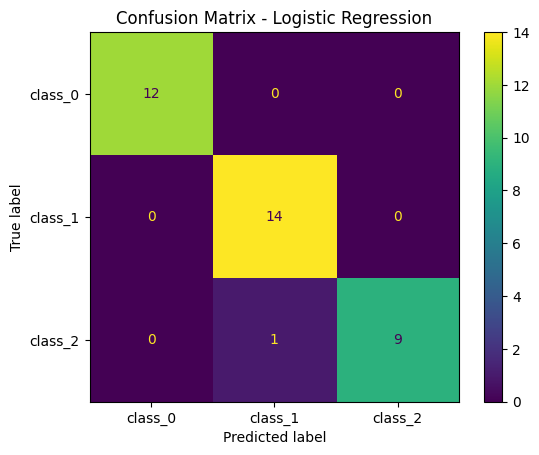

In [10]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=wine.target_names))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=wine.target_names
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



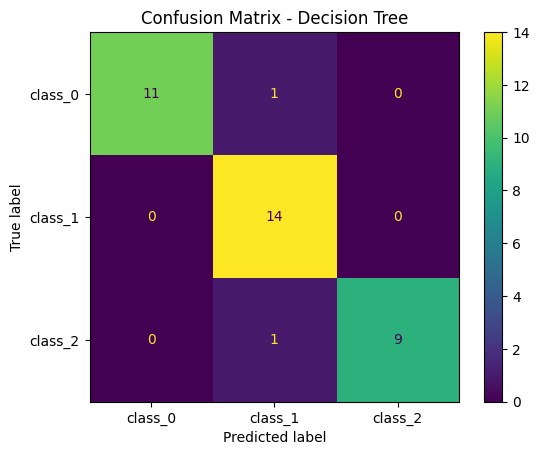

In [11]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree, target_names=wine.target_names))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree,
    display_labels=wine.target_names
)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Accuracy: 1.0
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



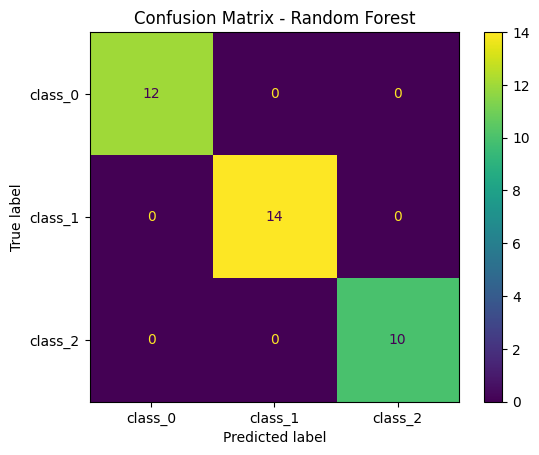

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=wine.target_names))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=wine.target_names
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [13]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.972222
1        Decision Tree  0.944444
2        Random Forest  1.000000


Wine dataset is a multiclass classification problem with 178 samples, 13 numeric features, and 3 classes. The dataset required minimal preprocessing because all features were numeric and there were no missing values. EDA showed that some chemical features such as alcohol, color intensity, and proline displayed noticeable variation across wine classes. Because feature scales differ substantially, standard scaling was applied before Logistic Regression. Logistic Regression, Decision Tree, and Random Forest were trained and compared. The confusion matrix helped identify whether any wine classes were harder to distinguish from each other, while Random Forest feature importances provided a rough indication of the most influential features.